In [448]:
%reload_ext autoreload
%autoreload 2

In [449]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from flax import nnx

from probjax.nn import GaussianFourierEmbedding
from probjax.nn.nets.denoising_diffusion_model import EDM
from probjax.nn.nets.simple import ResNet


In [450]:
def generate_data(key):
    # Mixture of Gaussians
    key, subkey = jax.random.split(key)
    theta = jax.random.normal(subkey, ())*3
    u = jax.random.uniform(subkey)
    eps = jax.random.normal(subkey, (2,))
    x = jnp.where(u < 0.5, eps[0]-theta, eps[1]+theta)
    return theta[None],x[None]

[2.124]


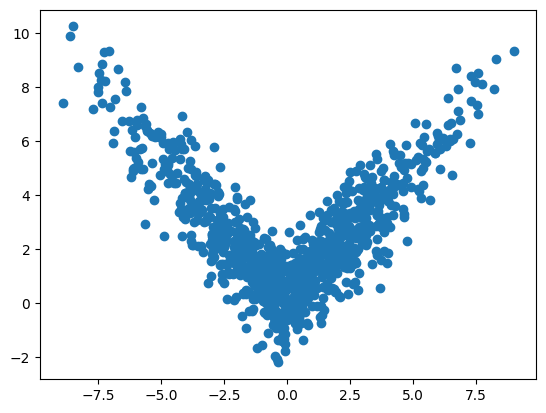

In [451]:
thetas, xs = jax.vmap(generate_data)(jax.random.split(jax.random.PRNGKey(0), 1000))
print(xs.std(0))
plt.scatter(thetas, xs)

In [452]:
d = 1
class BaseModel(nnx.Module, experimental_pytree=True):
    def __init__(self, d,d_context, rngs, time_embed_dim=8) -> None:
        self.time_embedding = GaussianFourierEmbedding(1,time_embed_dim, rngs=rngs)
        #self.time_embedding = lambda t: jnp.repeat(t, 5, axis=-1)
        self.resnet = ResNet(d,d,rngs,context_dim=2*time_embed_dim)

    def __call__(self, t,x, context, *args, **kwargs):
        time_embed = self.time_embedding(t)
        # Pad context by repeating until it matches the time embedding
        context_pad = jnp.repeat(context, time_embed.shape[-1]//context.shape[-1], axis=-1)
        context_emb = jnp.concatenate([context_pad, time_embed], axis=-1)

        # Run through resnet
        output = self.resnet(x, context_emb)
        return output

net = BaseModel(1, 1,nnx.Rngs(0))
model = EDM(net, std0=1.)
params = nnx.state(model, nnx.Param)

In [453]:
nnx.display(model)

In [467]:

import optax

scheduler_lr = optax.cosine_onecycle_schedule(500*20, 5e-4)
opt = optax.chain(optax.adaptive_grad_clip(10.), optax.ema(0.05), optax.adam(scheduler_lr))
opt_state = opt.init(params)
@jax.jit
def update(params, opt_state, x, rng):
    loss, grads = jax.value_and_grad(model.loss)(params,rng, x[0], context=x[1])
    updates, opt_state = opt.update(grads, opt_state, params=params)
    params = optax.apply_updates(params, updates)
    return params, opt_state, loss

In [468]:
key = jax.random.key(0)

In [469]:
losses = []
for i in range(500):
    l = 0.
    for j in range(20):
        key,key_data, key_loss = jax.random.split(key, 3)
        xs = jax.vmap(generate_data)(jax.random.split(key_data, 1000))
        params, opt_state, loss = update(params, opt_state, xs,key_loss)
        l += loss
    losses.append(l/20)

In [470]:
nnx.update(model, params)

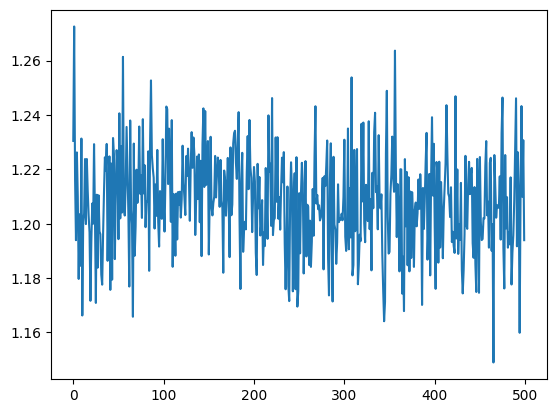

In [471]:
plt.plot(losses)

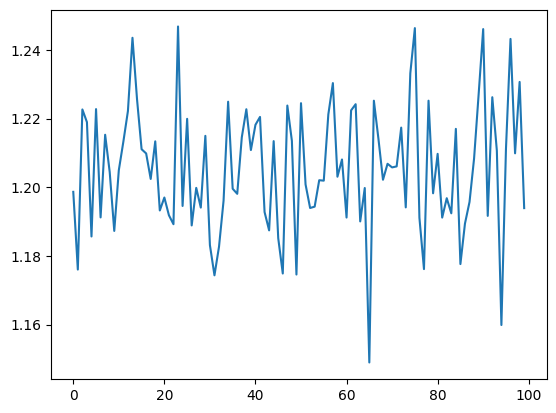

In [473]:
plt.plot(losses[-100:])

In [474]:
from probjax.utils.odeint import odeint


def sample(rng, context):
    eps = jax.random.normal(rng, (d,)) * model.marginal_std(model.max_noise)
    ts = model.solve_schedule(50)

    def drift(t, x):
        t = jnp.atleast_1d(t)
        f = model.drift(t,x)
        g = model.diffusion(t, x)
        score = model.score(t,x, context=context)
        return (f -0.5*g**2*score).reshape(x.shape)

    return odeint(drift, eps,ts, method="heun")


In [475]:
keys = jax.random.split(key,  (10_000,))

In [476]:
x_o = jnp.array([9.])
xs = jax.vmap(lambda k: sample(k, context=x_o))(keys)

(-10.0, 10.0)

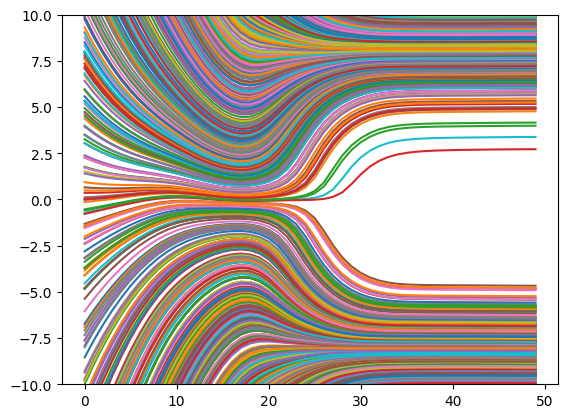

In [477]:
_ = plt.plot(xs[::10,:,0].T)
plt.ylim(-10,10)

In [478]:
# True posterior

def unnormalized_posterior(theta, x):
    prior = jax.scipy.stats.norm.logpdf(theta, 0., 3.)
    likelihood1 = jax.scipy.stats.norm.logpdf(x-theta, 0., 1.)
    likelihood2 = jax.scipy.stats.norm.logpdf(x+theta, 0., 1.)
    return prior + jax.scipy.special.logsumexp(jnp.array([likelihood1, likelihood2]))

thetas = jnp.linspace(-20,20,1000)
log_posterior = jax.vmap(lambda theta: jnp.mean(unnormalized_posterior(theta, x_o)))(thetas)
posterior_pdf = jnp.exp(log_posterior)
Z = jnp.trapezoid(posterior_pdf, thetas)
posterior_pdf /= Z

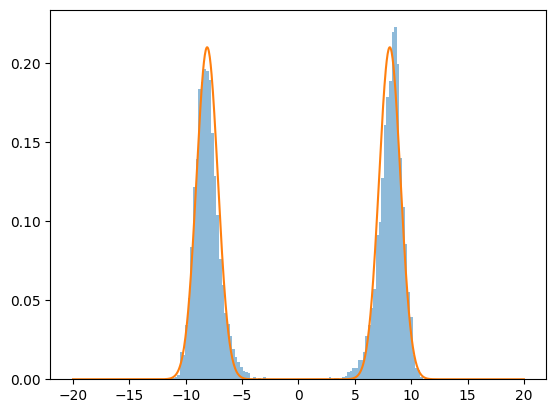

In [481]:
_ = plt.hist(xs[:,-1].flatten(), bins=100, density=True, alpha=0.5)
plt.plot(thetas, posterior_pdf)

In [499]:
from probjax.utils.sdeint import sdeint


def sample(rng, context):
    rng_init, rng_sample = jax.random.split(rng)
    eps = jax.random.normal(rng_init, (d,))  * model.marginal_std(model.max_noise)
    ts = model.solve_schedule(50)

    def drift(t, x):
        t = jnp.atleast_1d(t)
        f = model.drift(t,x)
        g = model.diffusion(t,x)
        score = model.score(t,x, context=context)

        drift_backward = f - g**2 * score
        return drift_backward

    def diffusion(t, x):
        t = jnp.atleast_1d(t)
        g = model.diffusion(t,x)
        return g

    return sdeint(rng_sample,drift, diffusion, eps, ts, method="euler_maruyama")





In [500]:
keys = jax.random.split(key, (10_000,))

In [501]:
xs = jax.vmap(lambda k: sample(k, context=x_o))(keys)

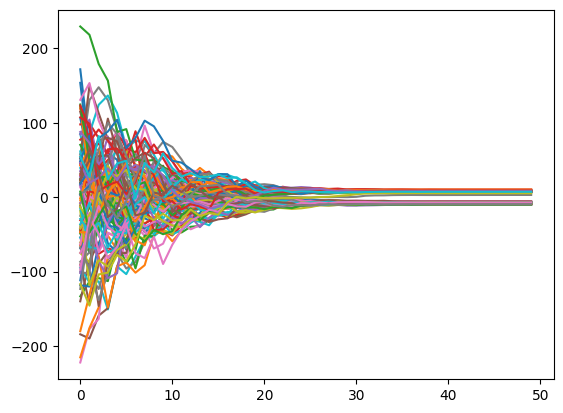

In [502]:
_ = plt.plot(xs[::100,:,0].T)

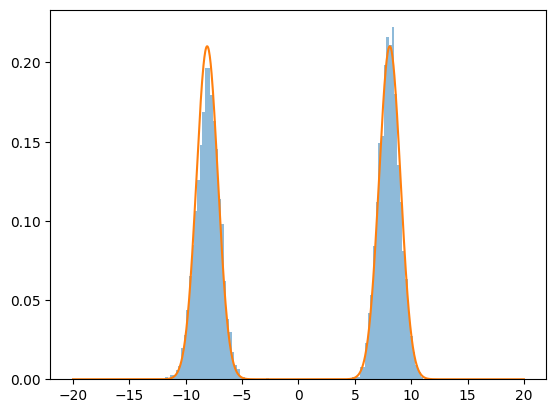

In [503]:
_ = plt.hist(xs[:,-1].flatten(), bins=100, density=True, alpha=0.5)
plt.plot(thetas, posterior_pdf)